# Predicción de Precios de Vehículos Usados (Core)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer, make_column_selector
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, root_mean_squared_error

In [2]:
cols = ['id', 'price', 'year', 'manufacturer', 'model', 'fuel', 'odometer', 'title_status', 'transmission', 'type', 'state']

df = pd.read_csv('vehicles.csv', usecols=cols)

In [3]:
print("Primeras filas del DataFrame:")
display(df.head(10))

print("Ultimas filas del DataFrame:")
print(df.tail(5))

print("Informacion del DataFrame:")
print(df.info())

print("Dimension del DataFrame:")
print(df.shape)

Primeras filas del DataFrame:


,id,price,year,manufacturer,model,fuel,odometer,title_status,transmission,type,state
0,7222695916,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az
1,7218891961,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar
2,7221797935,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl
3,7222270760,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma
4,7210384030,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc
5,7222379453,1600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
6,7221952215,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
7,7220195662,15995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ny
8,7209064557,5000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,or
9,7219485069,3000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,pa


Ultimas filas del DataFrame:
                id  price    year manufacturer                     model  \
426875  7301591192  23590  2019.0       nissan         maxima s sedan 4d   
426876  7301591187  30590  2020.0        volvo  s60 t5 momentum sedan 4d   
426877  7301591147  34990  2020.0     cadillac          xt4 sport suv 4d   
426878  7301591140  28990  2018.0        lexus           es 350 sedan 4d   
426879  7301591129  30590  2019.0          bmw  4 series 430i gran coupe   

          fuel  odometer title_status transmission       type state  
426875     gas   32226.0        clean        other      sedan    wy  
426876     gas   12029.0        clean        other      sedan    wy  
426877  diesel    4174.0        clean        other  hatchback    wy  
426878     gas   30112.0        clean        other      sedan    wy  
426879     gas   22716.0        clean        other      coupe    wy  
Informacion del DataFrame:
<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879


In [4]:
print("Estadisticas descriptivas del DataFrame:")
print(df.describe())

Estadisticas descriptivas del DataFrame:
                 id         price           year      odometer
count  4.268800e+05  4.268800e+05  425675.000000  4.224800e+05
mean   7.311487e+09  7.519903e+04    2011.235191  9.804333e+04
std    4.473170e+06  1.218228e+07       9.452120  2.138815e+05
min    7.207408e+09  0.000000e+00    1900.000000  0.000000e+00
25%    7.308143e+09  5.900000e+03    2008.000000  3.770400e+04
50%    7.312621e+09  1.395000e+04    2013.000000  8.554800e+04
75%    7.315254e+09  2.648575e+04    2017.000000  1.335425e+05
max    7.317101e+09  3.736929e+09    2022.000000  1.000000e+07


In [5]:
print("Tipos originales:")
print(df.dtypes)

Tipos originales:
id                int64
price             int64
year            float64
manufacturer        str
model               str
fuel                str
odometer        float64
title_status        str
transmission        str
type                str
state               str
dtype: object


In [6]:
n_duplicados = df.duplicated().sum()
print(f"Filas duplicadas: {n_duplicados}")

Filas duplicadas: 0


In [7]:
print("Verificacion de datos nulos:")
print(df.isnull().sum())

Verificacion de datos nulos:
id                  0
price               0
year             1205
manufacturer    17646
model            5277
fuel             3013
odometer         4400
title_status     8242
transmission     2556
type            92858
state               0
dtype: int64


In [8]:
cat_cols = ['manufacturer', 'model', 'fuel', 'title_status', 'transmission', 'type']
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [9]:
num_cols = ['year', 'odometer']
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [10]:
df.isnull().sum().sum()

np.int64(0)

Corregir Inconsistencias

In [11]:
categorical_cols = df.select_dtypes(include=['object', 'string']).columns
for col in categorical_cols:
    df[col] = df[col].str.lower().str.strip()

In [12]:
df = df[(df['price'] > 500) & (df['price'] < 100000)]

In [13]:
df = df[df['odometer'] < 500000]

Histogramas

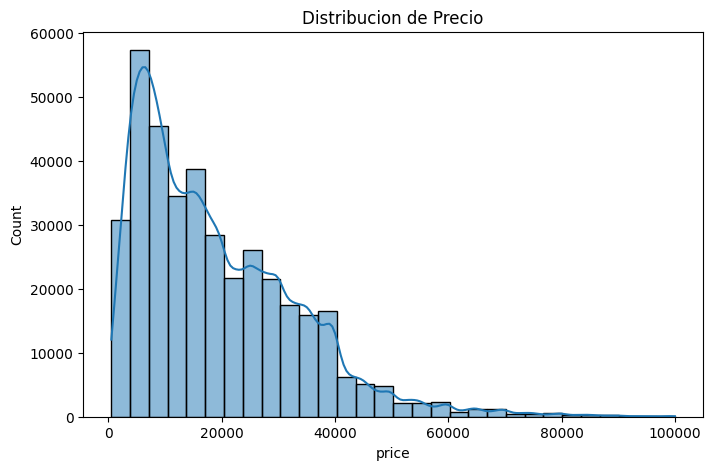

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], bins=30, kde=True)
plt.title('Distribucion de Precio')
plt.show()

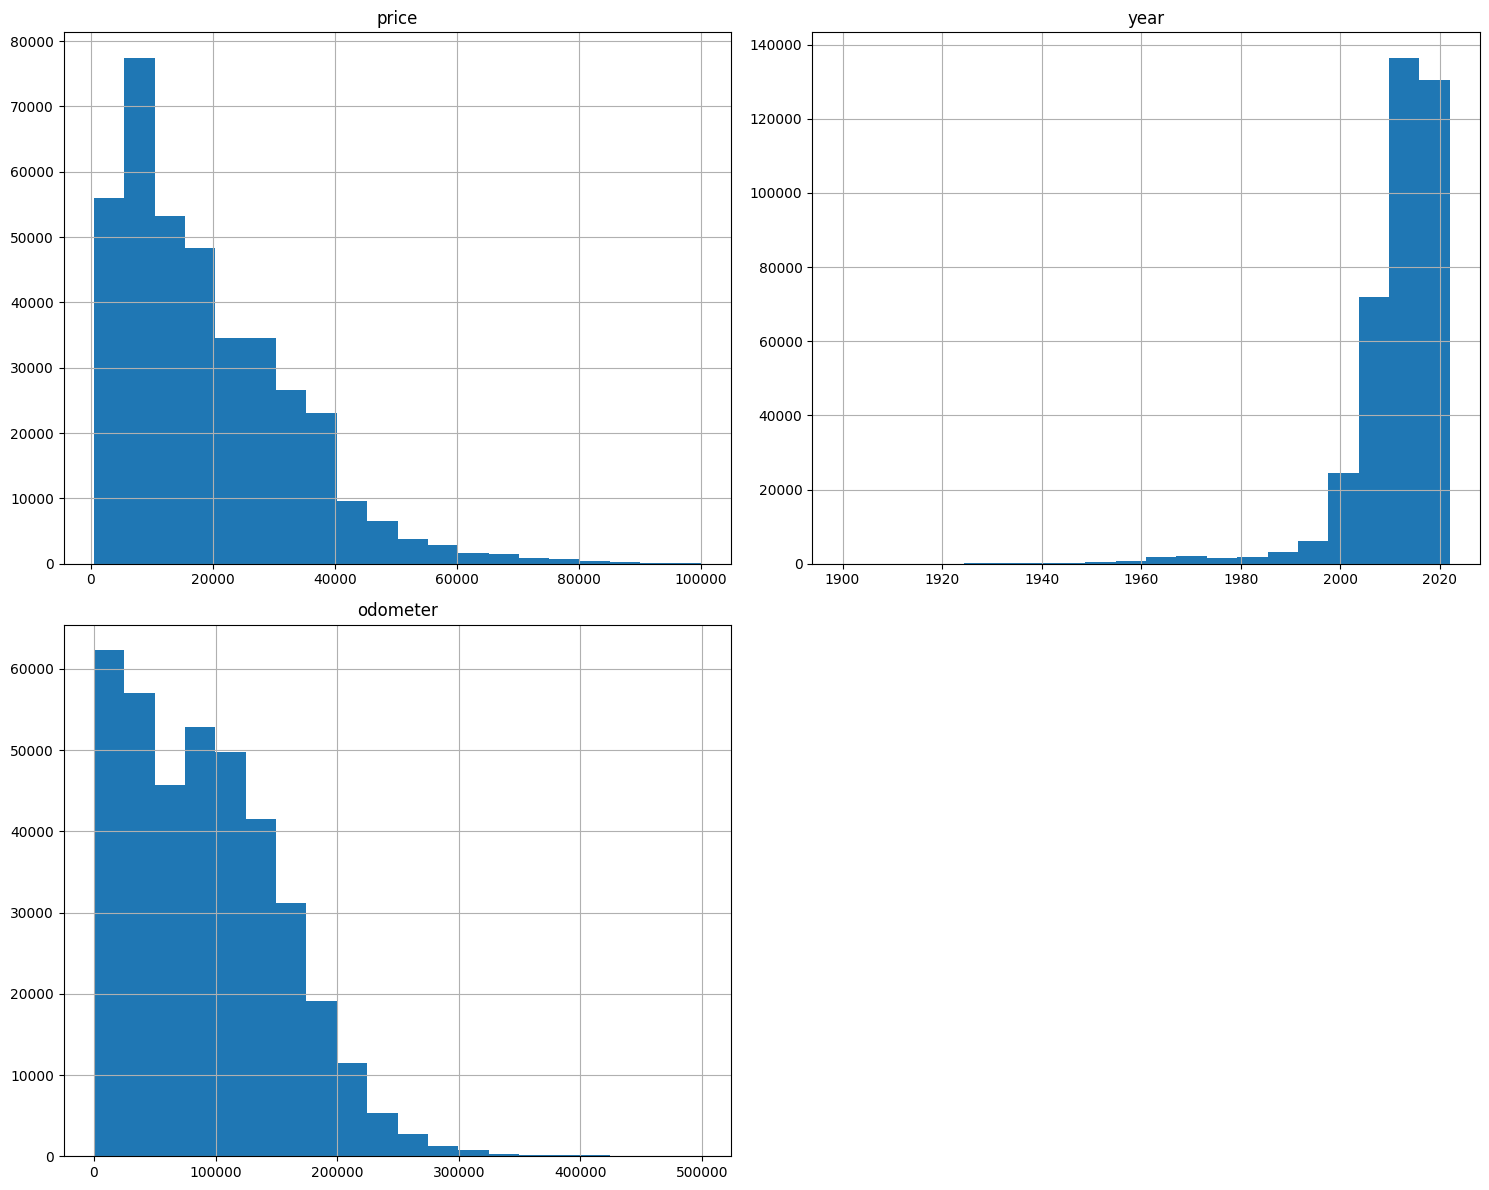

In [15]:
df.drop(columns=['id']).hist(figsize=(15,12), bins=20)
plt.tight_layout()
plt.show()

Outliers

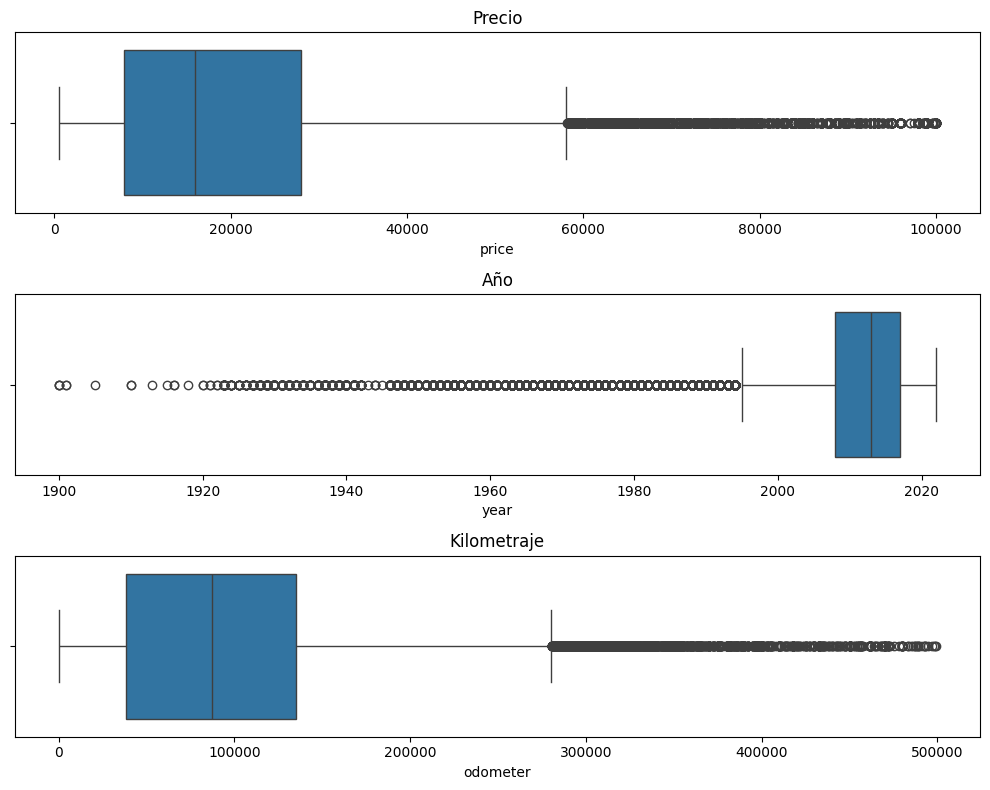

In [17]:
fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=False)
sns.boxplot(x=df['price'], ax=axes[0])
axes[0].set_title('Precio')
sns.boxplot(x=df['year'], ax=axes[1])
axes[1].set_title('Año')
sns.boxplot(x=df['odometer'], ax=axes[2])
axes[2].set_title('Kilometraje')
plt.tight_layout()
plt.show()

Correlacion numerica

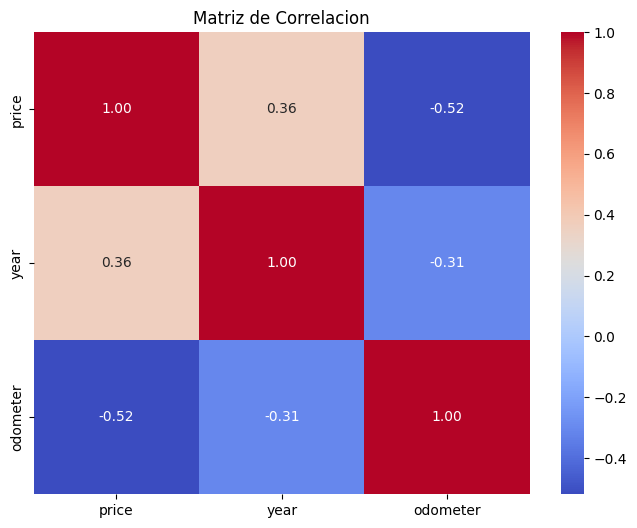

In [18]:
corr_df = df.drop(columns=['id'])
plt.figure(figsize=(8,6))
sns.heatmap(corr_df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de Correlacion')
plt.show()

**Conclusiones EDA**

Inicialmente comence utilizando el dataset completo pero era bastante grande y tenia muchas columnas con porcentajes altos de nulos por lo tanto decidi seleccionar solo 11 columnas para trabajar con ellas desde el comienzo ya que considero que estas columnas pueden generar un mejor analisis, las columnas seleccionadas fueron id, price, year, manufacturer, model, fuel, odometer, title_status, transmission, type y state. Las columnas que se dejaron fuera fueron por que tenian un alto porcentaje de nulos o se considero que no aportaban valor predictivo.
Independiente toda la seleccion realizada igualmente tenemos datos nulos en las columnas pero estos son porcentajes bastantes menores. Para las columnas categoricas decidi usar la moda ya que considero que es una buena opcion para el tipo de datos que tenemos, para las columnas numericas se utilizo la mediana debido a la presencia de distribuciones asimetricas y valores atipicos. La mediana es una medida mas robusta que la media frente a valores extremos, por lo que permite imputar los datos faltantes sin distorsionar significativamente la distribucion original de las variables.
Ademas se decidio dejar la columna ID principalmente por que al sacarla genera datos "duplicados" y considere que si bien no es una columna que utilizare para graficos o modelos de prediccion mas que nada era necesario mantener una identificacion de cada fila.

Luego se corrigieron inconsistencias con las columnas categoricas y con precio (price) y kilometraje (odometer).

Para el grafico 1 la variable precio presenta una distribucion asimetrica positiva, donde la mayoria de los vehiculos se concentra en rangos de precio bajos y medios. Ademas, se observan valores extremos elevados, lo que evidencia presncia de posibles outliers y alta variabilidad en los precios de vehiculos publicados. Esta distribucion es consistente con el comportamiento esperado del mercado de vehiculos usados, donde existe una pequeña proporcion de vehiculos de alto valor economico.

Para el grafico 2 las variables numericas analizadas presentan distribuciones no normales y en varios casos muetrasn asimetria positiva. Tanto precio como kilometraje evidencian presencia de valores extremos, mientras que año concentra la mayoria de las observaciones en vehiculos modernos. Estas caracteristicas sugieren la necesidad de considerar tecnicas robustas de modelado y tratamiento de outliers durante el preprocesamiento.

Para los boxplots, podemos observar lo siguiente; La variable precio presenta alta dispersion y numerosos valores atipicos en la parte superior de la distribucion, estos registros corresponden a vehiculos con precios significativamente superiores al promedio y prodrian estar asociados a vehiculos de lujo, modelos especiales o vehiculos con caracteristicas particulares que incrementan su valor de mercado.
La variable año muestra una fuerte concentracion de observaciones entre los años 2005 y 2022, lo que indica que la mayoria de los vehiculos publicados son relativamente modernos. Sin embargo, se observan numerosos valores atipicos inferiores correspondientes a vehiculos antiguos. Estos registros pueden representar vehiculos clasicos, de coleccion o simplemente automoviles mas antiguos que continuan formando parte del mercado de vehiculos usados.
La variable kilometraje presenta un distribucion con asimetria positiva y una importante cantidad de valores atipicos superiores. Esto indica la existencia de vehiculos con niveles de uso considerablemente mayores al promedio. Aunque algunos de estos casos podrian corresponder a registros poco frecuentes, muchos representan vehiculos reales con un alto kilometraje acumulado.
Aunque se aplicaron filtros para eliminar valores extremos inconsistentes en precio y kilometraje, los boxplots continuan mostrando observaciones atipicas. Esto se debe a que el criterio estadistico del boxplot identifica valores alejados de la distribucio central, incluso cuando representan registros validos dentro del mercado de vehiculos usados. Por esta razon, se decidio conservar dichos valores con el fin de mantener la representatividad y variabilidad propia del mercado de vehiculos usados.

La matriz de correlacion evidencia relaciones coherentes entre las variables numericas analizadas. El kilometraje presenta la relacion mas fuerte con el precio, mostrando una correlacion moderada negativa, mientras que el año del vehiculo se realciona positivamente con el precio. Estos resultados sugieren que tanto la antiguedad como el uso acumulado del vehiculo son factores relevantes para explicar el valor de mercado de los automoviles usados.

En terminos generales, el analisis exploratorio permitio identificar que el precio de los vehiculos esta influenciado principalmente por la antiguedad y el kilometraje. Los vehiculos mas nuevos tienden a presentar valores mas elevados, mientras que aquellos con mayor kilometraje muestran una disminucion en su valor de mercado. Asimismo, se observo una alta variabilidad en los precios, lo que sugiere la existencia de factores adicionales no incluidos en el analisis, como equipamiento, version especifica del vehiculo o estado mecanico.

**Modelado y Evaluacion**

In [19]:
df = df.sample(30000, random_state=42)

In [20]:
X = df.drop(columns=['price', 'id', 'model'])
y = df['price']

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
numeric_transformer = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler())])

categorical_transformer = Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))])

In [23]:
preprocessor = make_column_transformer((numeric_transformer, make_column_selector(dtype_include=np.number)), (categorical_transformer, make_column_selector(dtype_include=['object', 'string'])))

In [24]:
linear_model = Pipeline([('Preprocessor', preprocessor), ('model', LinearRegression())])
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)

In [25]:
mse_lr = mean_squared_error(y_test, y_pred_linear)
rmse_lr = np.sqrt(mse_lr)
r2_lr = r2_score(y_test, y_pred_linear)
print('Regresion Lineal')
print(f'MSE: {mse_lr:,.3f}')
print(f'RMSE: {rmse_lr:,.3f}')
print(f'R2: {r2_lr:.3f}')

Regresion Lineal
MSE: 87,410,799.911
RMSE: 9,349.374
R2: 0.574


In [26]:
rf_pipeline = Pipeline([('preprocessor', preprocessor), ('model', RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1))])
rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)

In [27]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
r2_rf = r2_score(y_test, y_pred_rf)
print('Random Forest')
print(f'MSE: {mse_rf:,.3f}')
print(f'RMSE: {rmse_rf:,.3f}')
print(f'R2: {r2_rf:.3f}')

Random Forest
MSE: 57,501,798.818
RMSE: 7,582.994
R2: 0.720


In [31]:
results = pd.DataFrame({'Modelo': ['Regresion Lineal', 'Random Forest'], 'MSE': [mse_lr, mse_rf], 'R2': [r2_lr, r2_rf], 'RMSE': [rmse_lr, rmse_rf]})
results.style.format({'MSE': '{:,.3f}', 'RMSE': '{:,.3f}', 'R2': '{:.3f}'})

,Modelo,MSE,R2,RMSE
0,Regresion Lineal,"87,410,799.911",0.574,"9,349.374"
1,Random Forest,"57,501,798.818",0.720,"7,582.994"


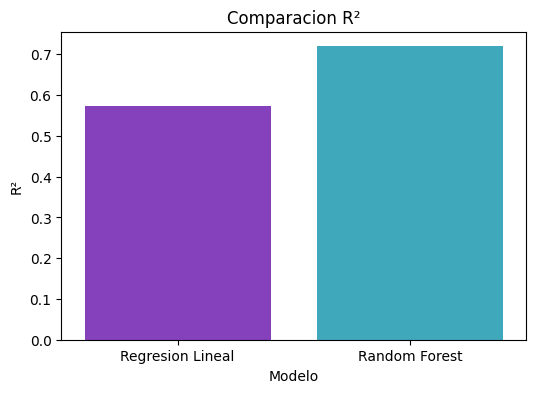

In [32]:
plt.figure(figsize=(6,4))
sns.barplot(data=results, x='Modelo', y='R2', hue='Modelo', palette=['#882BCF','#2BB6CF'], legend=False)
plt.title('Comparacion R²')
plt.ylabel('R²')
plt.xlabel('Modelo')
plt.show()

**Conclusiones Benchmarking**

In [33]:
param_grid = {'model__n_estimators': [100, 200], 'model__max_depth': [10, 20], 'model__min_samples_split': [2,5]}
grid_search =GridSearchCV(rf_pipeline, param_grid, cv=3, scoring='r2', n_jobs=-1)
grid_search.fit(X_train, y_train)
print(grid_search.best_params_)
best_model = grid_search.best_estimator_

{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 200}


In [35]:
y_pred_best = best_model.predict(X_test)

mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test, y_pred_best)
print(f'Modelo Optimizado')
print(f'MSE: {mse_best:,.3f}')
print(f'RMSE: {rmse_best:,.3f}')
print(f'R2: {r2_best:.3f}')

Modelo Optimizado
MSE: 58,141,003.204
RMSE: 7,625.025
R2: 0.716


**Conclusion final**

Debido al tamaño del dataset se realizo el modelado con una muestra ya que al ejecutar randomforest este estaba tardando bastante, por lo tanto al reducir la muestra esto funciona bastante mejor.

El modelo de Regresion Lineal obtuvo un coeficiente de determinacion (R2) de 0,574, lo que indica que logra explicar aproximadamente el 57,4% de la variabilidad observada en los precios de los vehiculo. Asimismo, presento un RMSE de 9349 dolares, reflejando un error promedio moderado en las predicciones. Estos resultados sugieren que existe una relacion lineal significativa entre las variables explicativas y el precio.

El modelo Random Forest Regressor obtuvo el mejor desempeño entre los modelos evaluados, alcanzando un R2 de 0,72 superior al 0.57 obtenido por la Regresion Lineal. Asimismo, presento una reduccion significativa del error, con un RMSE de 7583 USD frente a los 9349 del modelo lineal. Estos resultado indican que Random Forest captura de mejor manera las relaciones complejas y no lineales presentes en los datos, convirtiendose en el modelo seleccionado para la etapa de optimizacion mediante GridSearchCV.

Tras aplicar GridSearchCV para optimizar los hiperparametros del modelo Random Forest Regressor, los resultado obtenidos fueron muy similares a los del modelo original. Sin embargo, el modelo optimizado presento un ligero aumento en el error (RMSE) y una pequeña disminucion en el coeficiente R2. Esto indica que la optimizacion no produjo mejoras significativas en la capacidad predictiva del modelo.

Se evaluaron dos modelos de regresion para predecir el precio de vehiculos usados: Regresion Lineal y Random Forest Regressor. El modelo Random Forest obtuvo el mejor desempeño, alcanzando un R2 de 0.72 y un RMSE de 7583 USD. Posteriormente se aplico GridSearchCV para optimizar sus hiperparametros; sin embargo, el modelo optimizado no logro superar el rendimiento del modelo original. Por esta razon, yo seleccionaria el Random Forest inicial como el modelo final del proyecto.

Los resultados obtenidos demuestran que es posible estimar el precio de vehiculos usados con un nivel de precision aceptable utilizando informacion basica de las publicaciones. Sin embargo, aun existe una proporcion de variabilidad no explicada, lo que sugiere que incorporar variables adicionales relacionadas con las caracteristicas especificas del vehiculo podria mejorar el rendimiento predictivo en futuros trabajos.

Una limitacion importante del estudio fue la necesidad de trabajar con una muestra del dataset debido a alto costo computacional asociado al entrenamiento del modelo Random Forest sobre el conjunto completo de datos. A pesar de ello, la muestra seleccionada permitio obtener resultados consistentes y realizar una comparacion valida entre los distintos modelos evaluados.
